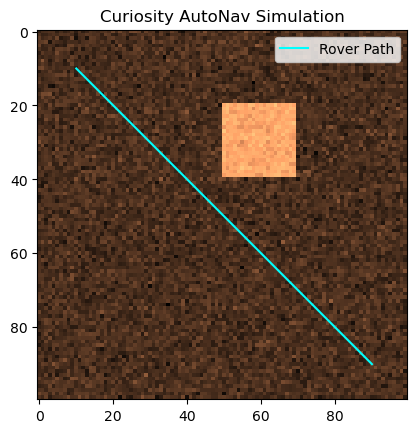

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a 100x100 meter patch of Martian terrain (Gale Crater)
terrain = np.random.normal(0, 0.5, (100, 100)) # Random bumps
terrain[20:40, 50:70] += 5  # A large "rock" (hazard)

def simulate_rover_path(start, end):
    # This is a simplified "Greedy" path - it always moves toward the goal
    # unless the terrain is too high (slope > 20 degrees)
    path = [start]
    curr = np.array(start)
    
    for _ in range(200):
        direction = np.array(end) - curr
        step = np.sign(direction)
        next_pos = curr + step
        
        # Hazard Check: Is the rock too tall?
        if terrain[next_pos[0], next_pos[1]] > 2:
            next_pos = curr + [1, 0] # Attempt to sidestep
            
        curr = next_pos
        path.append(tuple(curr))
        if np.array_equal(curr, end): break
        
    return np.array(path)

path = simulate_rover_path((10,10), (90,90))

plt.imshow(terrain, cmap='copper')
plt.plot(path[:,1], path[:,0], color='cyan', label='Rover Path')
plt.title("Curiosity AutoNav Simulation")
plt.legend()
plt.show()